# Install Libraries

In [1]:
!pip install gradio matplotlib numpy pandas seaborn scikit-learn joblib

# Import Libraries

In [12]:
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Load Dataset

In [3]:
df=pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Number of rows and columns

In [4]:
print(df.shape)

(150, 6)


# Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# Statistical Summary

In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Check Missing Values

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


# Remove Duplicate Records

In [6]:
print("Duplicates Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


# Species Distribution

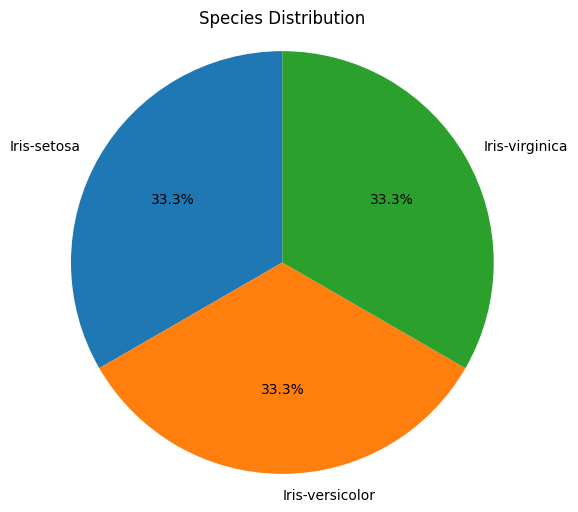

In [7]:
plt.figure(figsize=(6,6))

species_counts = df["Species"].value_counts()

plt.pie(
    species_counts,
    labels=species_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Species Distribution")
plt.axis("equal")

plt.show()

# Convert Categorical Labels to Numbers

In [8]:
target = {
    "Iris-versicolor": 0,
    "Iris-virginica": 1,
    "Iris-setosa": 2
}

df["Species"] = df["Species"].map(target)

# Remove Unnecessary Column

In [9]:
df.drop(columns=["Id"], inplace=True)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,2
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,2


# Numerical Columns

In [10]:
num_cols = df.select_dtypes(include=["float64"]).columns

num_cols

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')

# Histogram and KDE Plots

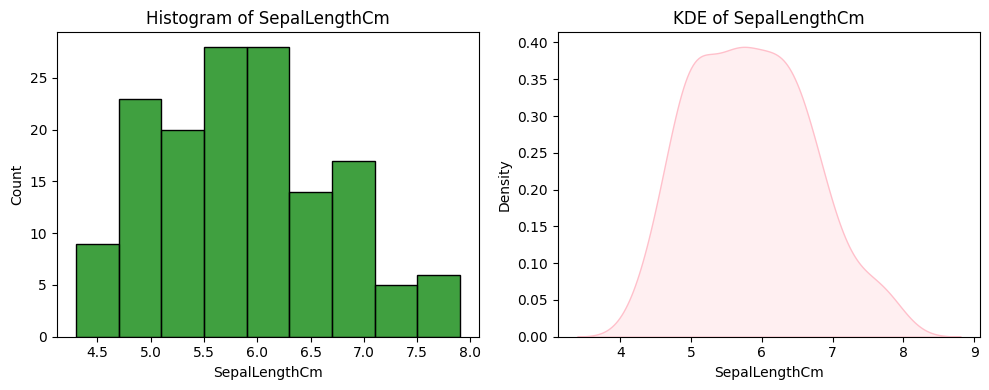

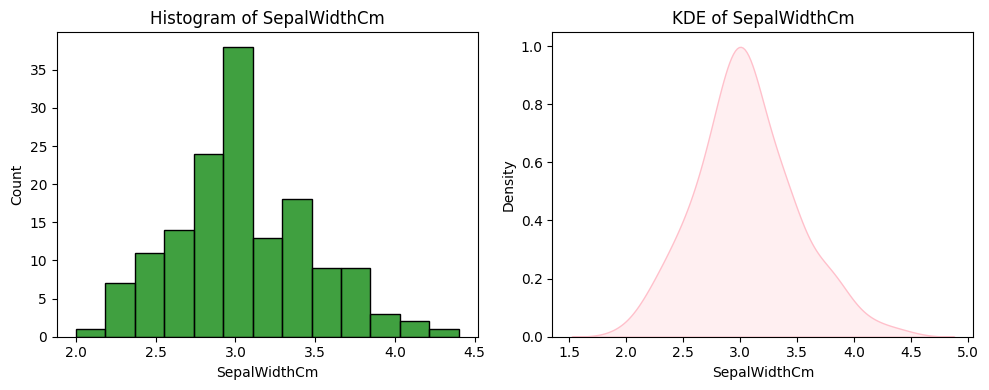

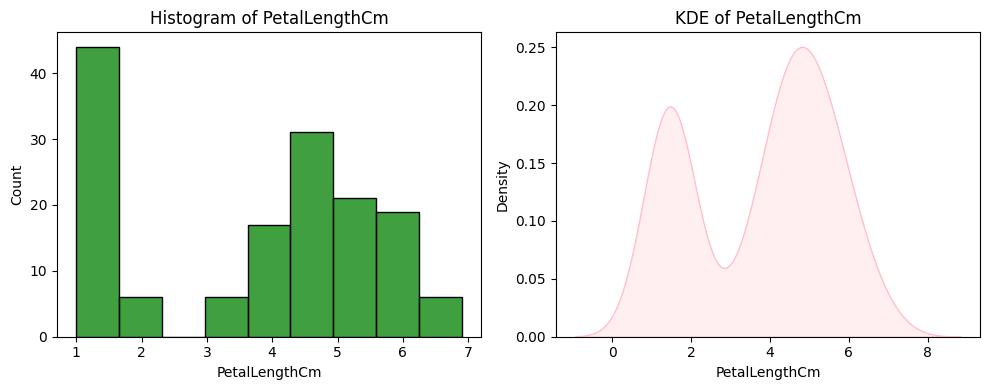

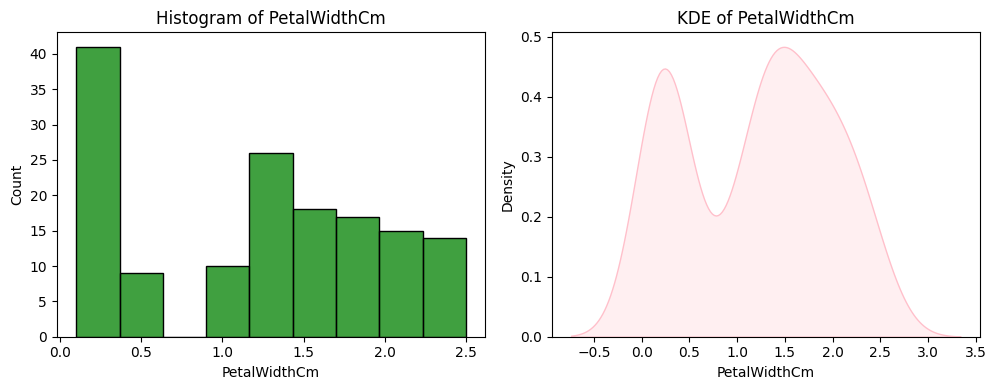

In [13]:
for col in num_cols:

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)

    sns.histplot(
        df[col],
        color="green",
        edgecolor="black"
    )

    plt.title(f"Histogram of {col}")

    plt.subplot(1,2,2)

    sns.kdeplot(
        df[col],
        fill=True,
        color="pink"
    )

    plt.title(f"KDE of {col}")

    plt.tight_layout()

    plt.show()

# Boxplot and Violin Plot

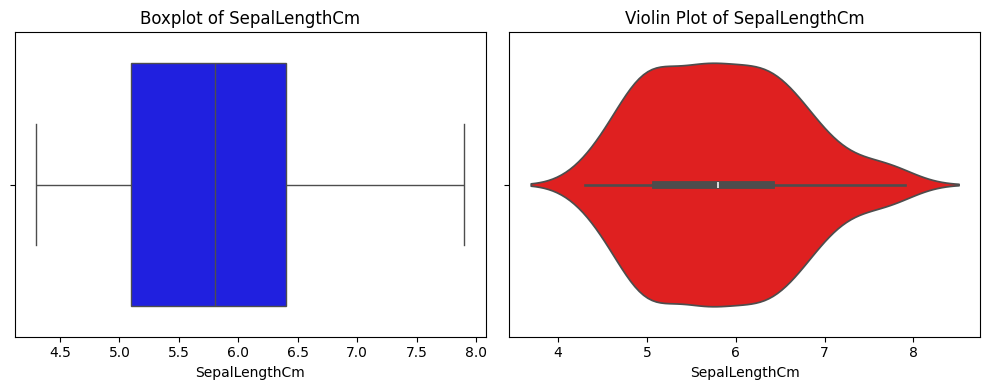

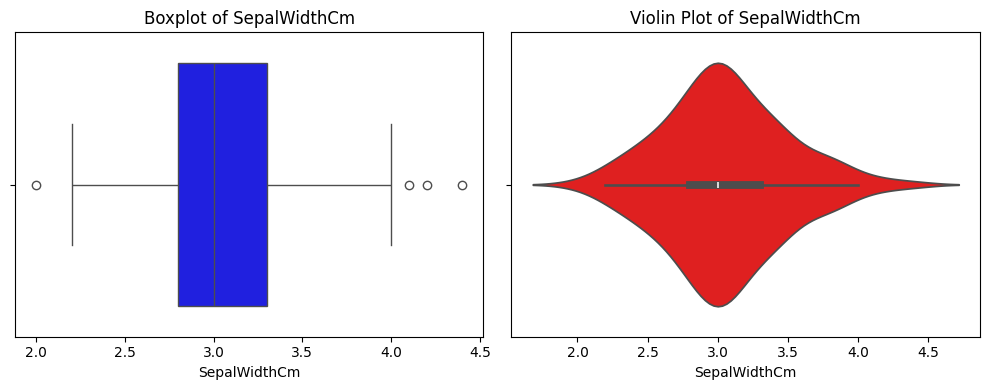

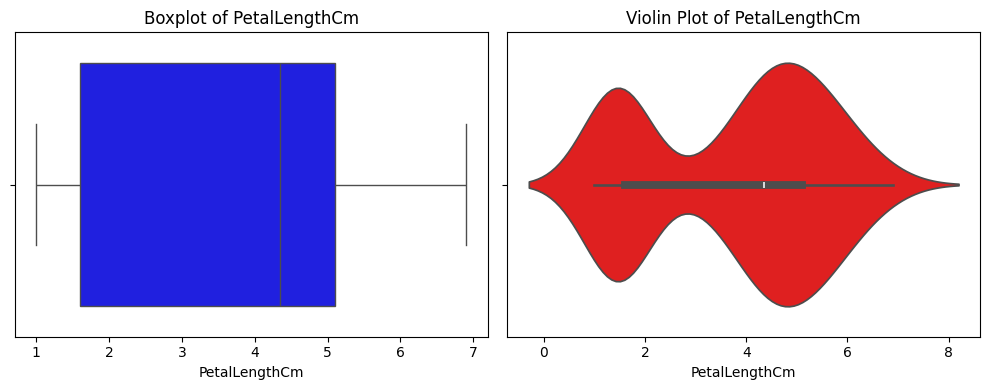

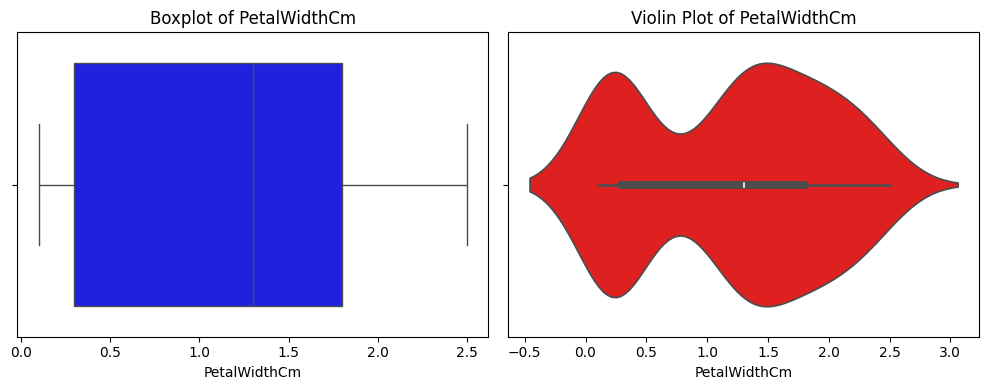

In [14]:
for col in num_cols:

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)

    sns.boxplot(
        x=df[col],
        color="blue"
    )

    plt.title(f"Boxplot of {col}")

    plt.subplot(1,2,2)

    sns.violinplot(
        x=df[col],
        color="red"
    )

    plt.title(f"Violin Plot of {col}")

    plt.tight_layout()

    plt.show()

# Correlation Heatmap

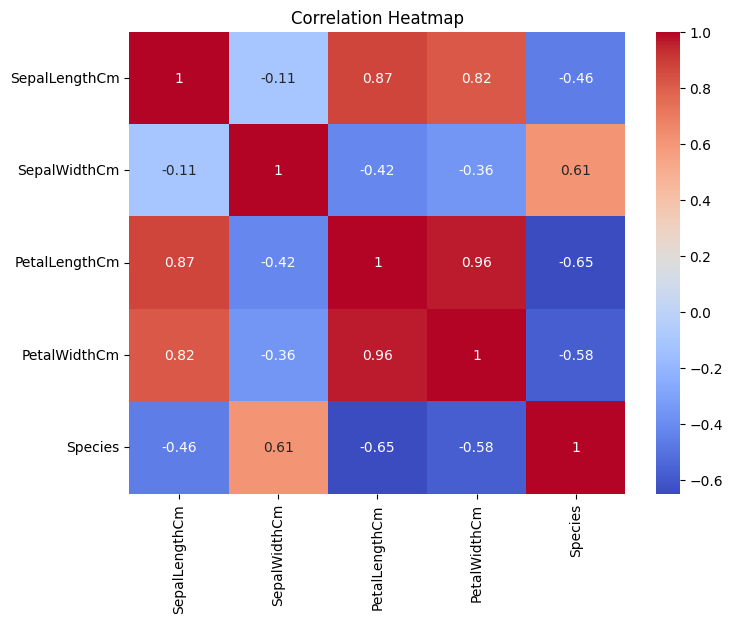

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Pair Plot

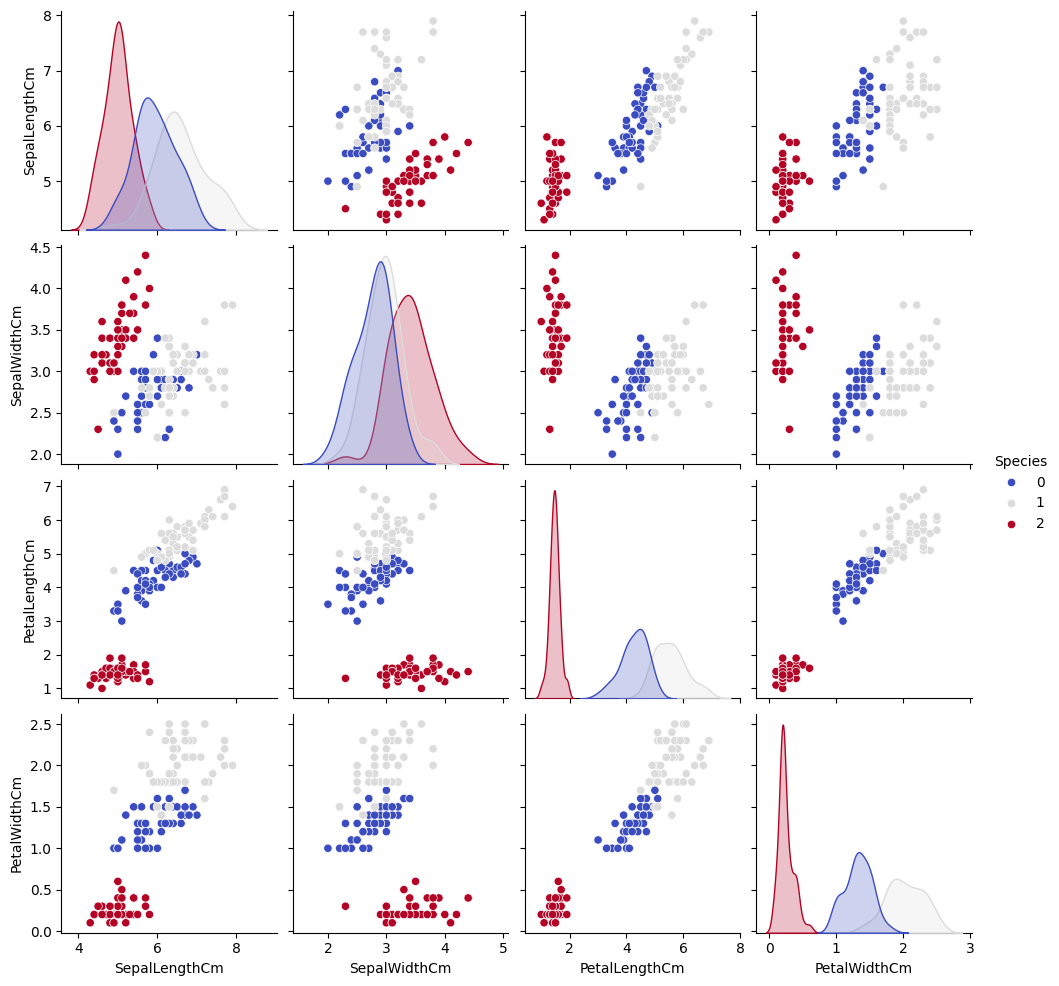

In [16]:
sns.pairplot(
    data=df,
    hue="Species",
    palette="coolwarm"
)

plt.show()

# Separate Features and Target

In [17]:
X = df.drop(columns=["Species"])

y = df["Species"]

# Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Generic Model Evaluation Function

Random Forest Classifier:
Accuracy: 1.0


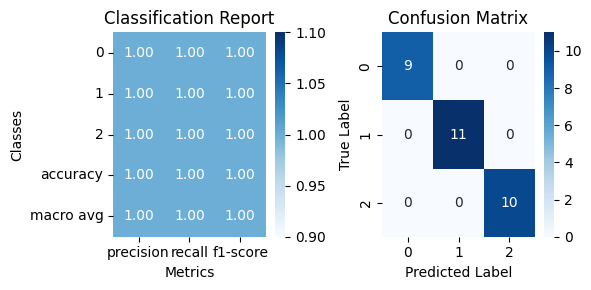

In [27]:
# Train the model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
# Predict
y_pred = rf.predict(X_test)
# Accuracy
print("Random Forest Classifier:")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# --- Side-by-Side Plot ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
# Heatmap for Classification Report
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Classification Report")
axes[0].set_xlabel("Metrics")
axes[0].set_ylabel("Classes")
# Heatmap for Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_, ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
# Adjust layout
plt.tight_layout()
plt.show()


# Model Deployment


In [29]:
import joblib
#save model
joblib.dump(rf,"model.pkl")
print("Model saved as model.pkl")

Model saved as model.pkl


# Load Saved Model

In [32]:
model = joblib.load("model.pkl")

# Prediction FunctionPrediction Function

In [33]:
species_map = {

    0:"Iris-versicolor",

    1:"Iris-virginica",

    2:"Iris-setosa"
}

def predict_iris(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
):

    sample = np.array([
        [
            sepal_length,
            sepal_width,
            petal_length,
            petal_width
        ]
    ])

    sample = scaler.transform(
        sample
    )

    prediction = model.predict(
        sample
    )[0]

    return species_map[
        prediction
    ]

# Gradio Web Application

In [34]:
app = gr.Interface(
    fn=predict_iris,

    inputs=[
        gr.Number(
            label="Sepal Length"
        ),

        gr.Number(
            label="Sepal Width"
        ),

        gr.Number(
            label="Petal Length"
        ),

        gr.Number(
            label="Petal Width"
        )
    ],

    outputs=gr.Textbox(
        label="Predicted Species"
    ),

    title="Iris Flower Classification",

    description=
    "Predict Iris Species using the Best Machine Learning Model"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c0f9e897ad042ef2e2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
